In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import shap
import joblib

In [5]:
df = pd.read_csv("train.csv")
df.head()
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251681 entries, 0 to 251680
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       251681 non-null  int64  
 1   Age                      251681 non-null  int64  
 2   Sex                      251681 non-null  int64  
 3   Chest pain type          251681 non-null  int64  
 4   BP                       251681 non-null  int64  
 5   Cholesterol              251681 non-null  int64  
 6   FBS over 120             251681 non-null  int64  
 7   EKG results              251681 non-null  int64  
 8   Max HR                   251681 non-null  int64  
 9   Exercise angina          251681 non-null  int64  
 10  ST depression            251681 non-null  float64
 11  Slope of ST              251680 non-null  float64
 12  Number of vessels fluro  251680 non-null  float64
 13  Thallium                 251680 non-null  float64
 14  Hear

,0
id,0
Age,0
Sex,0
Chest pain type,0
BP,0
Cholesterol,0
FBS over 120,0
EKG results,0
Max HR,0
Exercise angina,0


In [6]:
df['Heart Disease'] = df['Heart Disease'].map({'Absence': 0, 'Presence': 1})
df['target'] = df['Heart Disease']
df.drop(['Heart Disease','id'], axis=1, inplace=True)

In [13]:
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,target
0,58,1,4,152,239,0,0,158,1,3.6,2.0,2.0,7.0,1.0
1,52,1,1,125,325,0,2,171,0,0.0,1.0,0.0,3.0,0.0
2,56,0,2,160,188,0,2,151,0,0.0,1.0,0.0,3.0,0.0
3,44,0,3,134,229,0,2,150,0,1.0,2.0,0.0,3.0,0.0
4,58,1,4,140,234,0,2,125,1,3.8,2.0,3.0,3.0,1.0


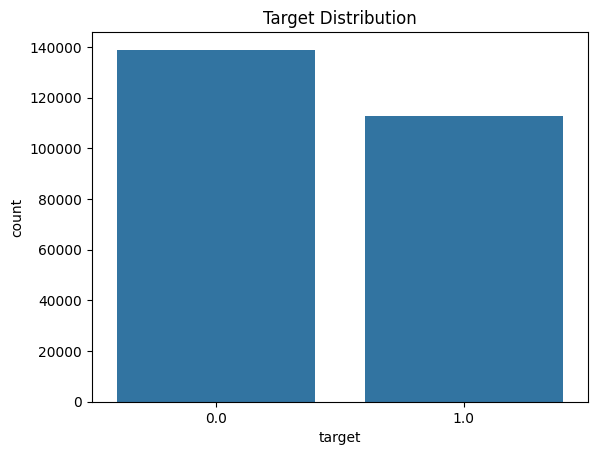

In [7]:
sns.countplot(x='target', data=df)
plt.title("Target Distribution")
plt.show()

In [8]:
df.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,target
count,251681.000000,251681.000000,251681.000000,251681.000000,251681.000000,251681.000000,251681.000000,251681.000000,251681.000000,251681.000000,251680.000000,251680.000000,251680.000000,251680.000000
mean,54.128758,0.714643,3.313730,130.514191,245.037575,0.080471,0.978795,152.814626,0.273497,0.714960,1.456087,0.451339,4.615464,0.448224
std,8.248374,0.451585,0.850124,14.984764,33.690612,0.272021,0.998735,19.142752,0.445755,0.948898,0.544583,0.799055,1.949429,0.497313
min,29.000000,0.000000,1.000000,94.000000,149.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,222.000000,0.000000,0.000000,142.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,54.000000,1.000000,4.000000,130.000000,243.000000,0.000000,0.000000,157.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
75%,60.000000,1.000000,4.000000,140.000000,269.000000,0.000000,2.000000,166.000000,1.000000,1.400000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


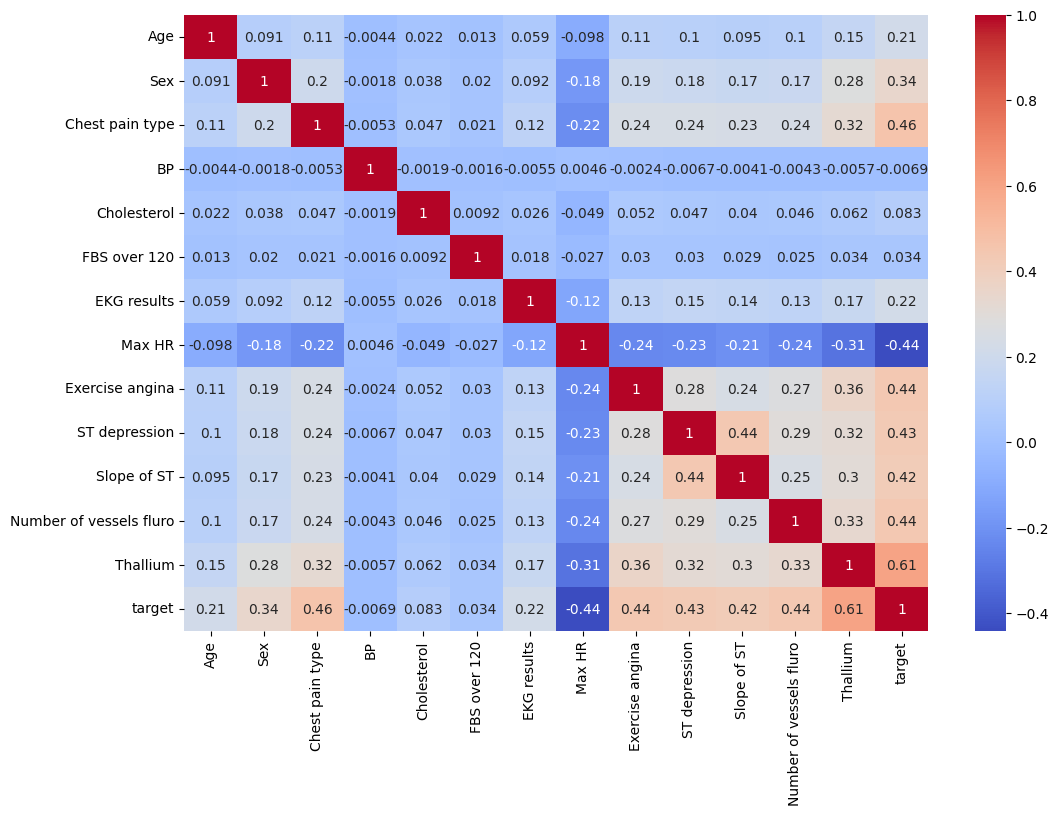

In [9]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

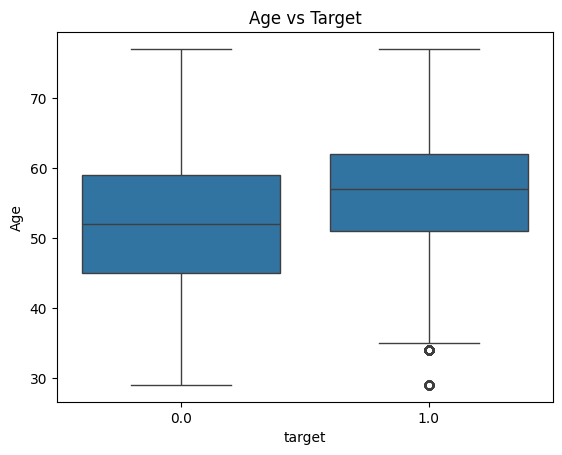

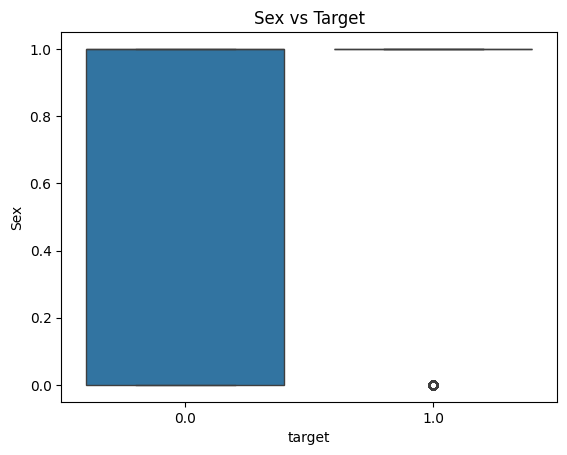

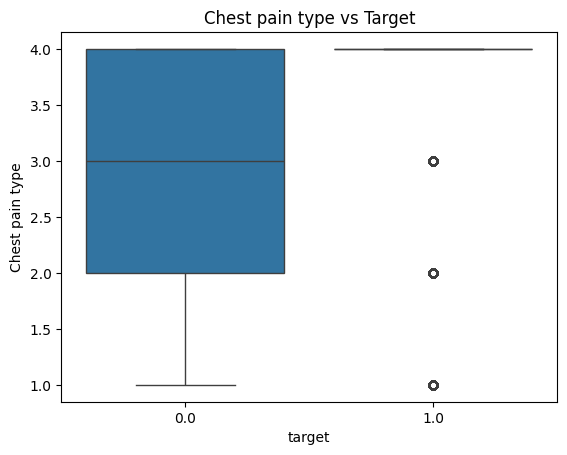

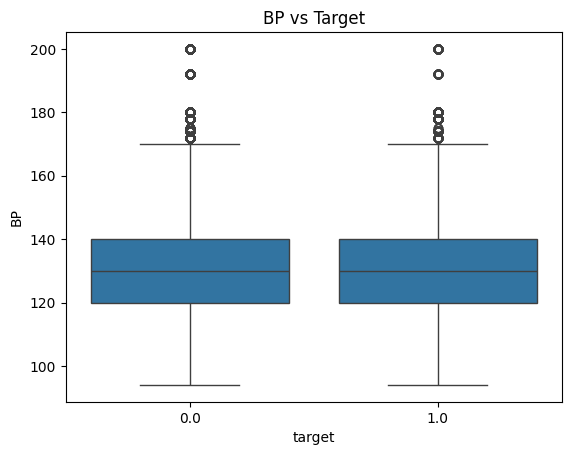

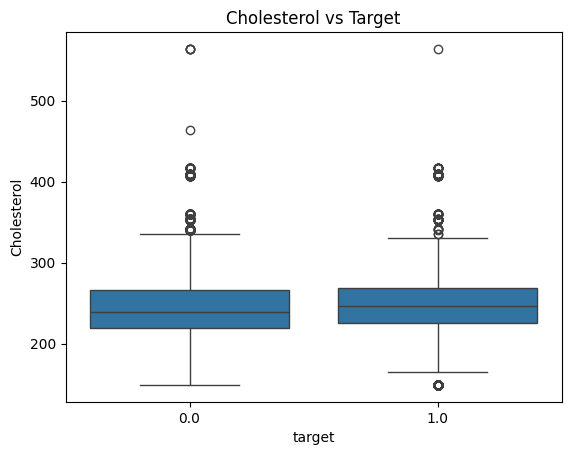

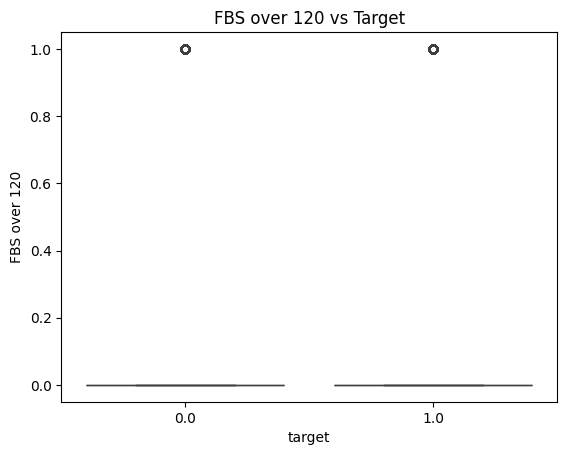

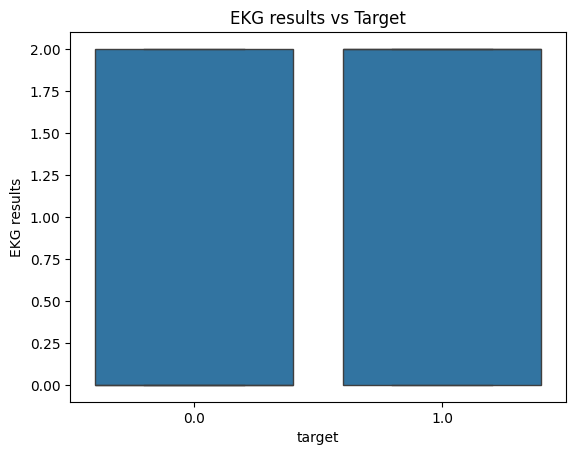

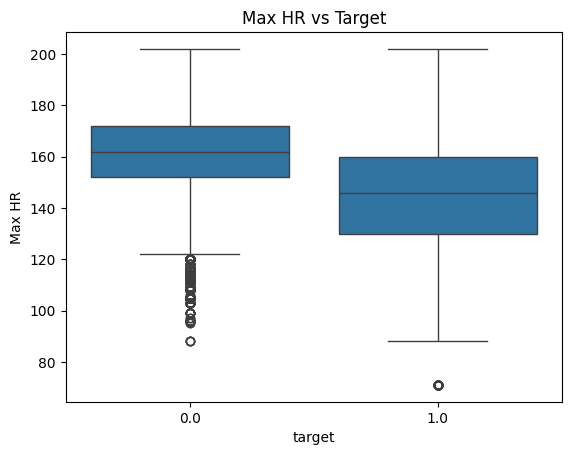

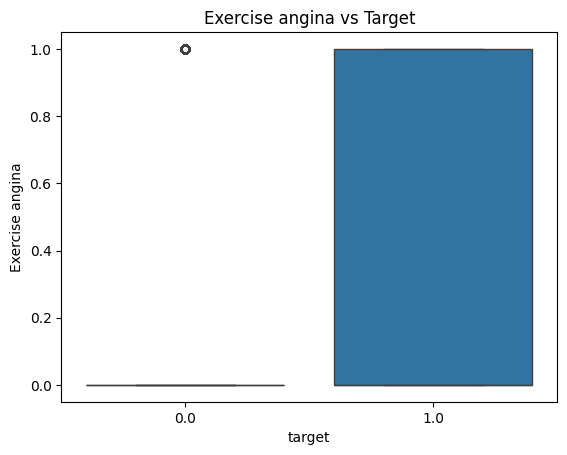

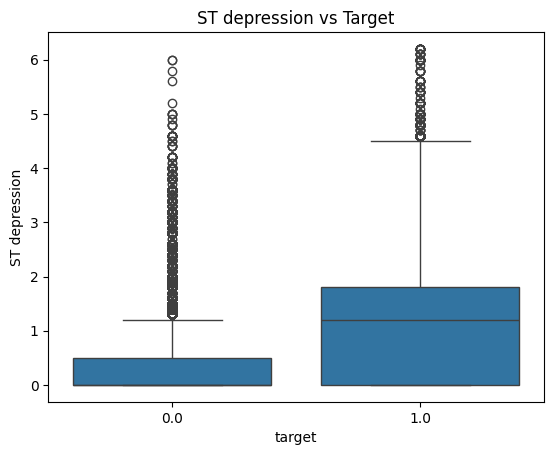

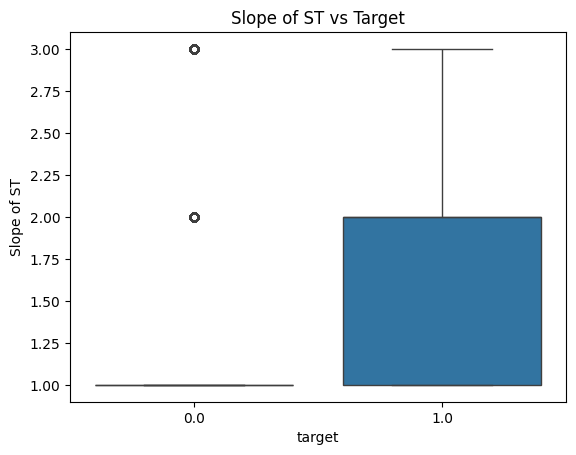

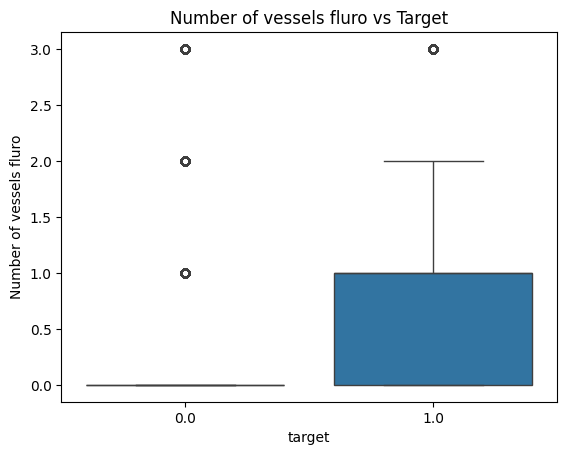

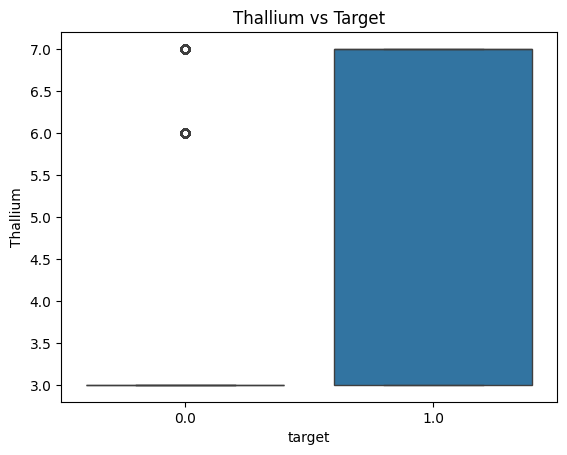

In [10]:
for col in df.columns:
    if col != "target":
        sns.boxplot(x='target', y=col, data=df)
        plt.title(f"{col} vs Target")
        plt.show()

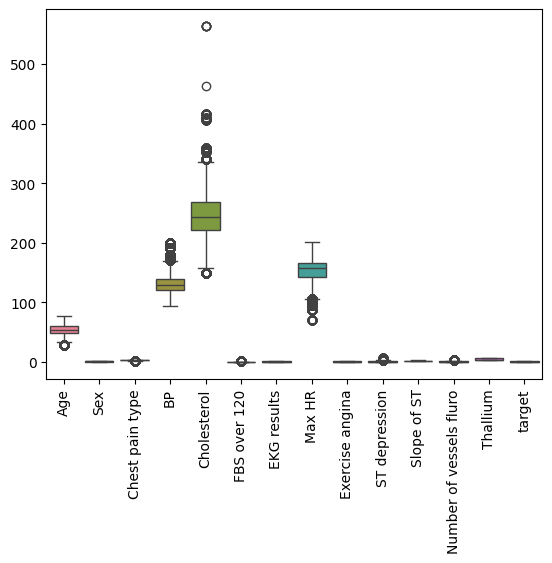

In [11]:
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

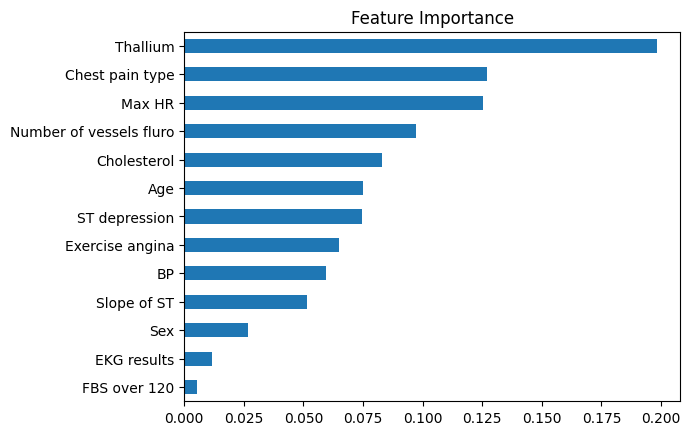

In [14]:
from sklearn.ensemble import RandomForestClassifier

# Drop rows where 'target' is NaN
df.dropna(subset=['target'], inplace=True)

X = df.drop('target', axis=1)
y = df['target']

rf = RandomForestClassifier()
rf.fit(X, y)

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title('Feature Importance')
plt.show()

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
from sklearn.metrics import classification_report, roc_auc_score

models = {
    "Logistic": LogisticRegression(),
    "RandomForest": RandomForestClassifier(),
    "XGBoost": XGBClassifier()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print("Model:", name)
    print(classification_report(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))
    print("-"*40)

Model: Logistic
              precision    recall  f1-score   support

         0.0       0.89      0.91      0.90     27774
         1.0       0.88      0.86      0.87     22562

    accuracy                           0.88     50336
   macro avg       0.88      0.88      0.88     50336
weighted avg       0.88      0.88      0.88     50336

ROC-AUC: 0.9504068869295663
----------------------------------------
Model: RandomForest
              precision    recall  f1-score   support

         0.0       0.89      0.90      0.89     27774
         1.0       0.87      0.86      0.87     22562

    accuracy                           0.88     50336
   macro avg       0.88      0.88      0.88     50336
weighted avg       0.88      0.88      0.88     50336

ROC-AUC: 0.9469119448148502
----------------------------------------
Model: XGBoost
              precision    recall  f1-score   support

         0.0       0.89      0.91      0.90     27774
         1.0       0.88      0.87      0.87     

In [18]:
from sklearn.ensemble import VotingClassifier

In [19]:
lr = LogisticRegression()
rf = RandomForestClassifier()
xgb = XGBClassifier()

In [20]:
voting = VotingClassifier(
    estimators=[
        ('lr', lr),
        ('rf', rf),
        ('xgb', xgb)
    ],
    voting='soft'
)

voting.fit(X_train, y_train)

VotingClassifier(estimators=[('lr', LogisticRegression()),
                             ('rf', RandomForestClassifier()),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None,
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=None, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=None,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=None, n_jobs=None,
                                            num_parallel_tree=None, ...))],
                 voting='soft')

In [21]:
y_pred = voting.predict(X_test)

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, voting.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

         0.0       0.89      0.91      0.90     27774
         1.0       0.88      0.87      0.87     22562

    accuracy                           0.89     50336
   macro avg       0.89      0.89      0.89     50336
weighted avg       0.89      0.89      0.89     50336

ROC-AUC: 0.9530753680949329


In [22]:
test_df = pd.read_csv("test.csv")
test_df.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
0,630000,58,1,3,120,288,0,2,145,1,0.8,2,3,3
1,630001,55,0,2,120,209,0,0,172,0,0.0,1,0,3
2,630002,54,1,4,120,268,0,0,150,1,0.0,2,3,7
3,630003,44,0,3,112,177,0,0,168,0,0.9,1,0,3
4,630004,43,1,1,138,267,0,0,163,0,1.8,2,0,7


In [23]:
if 'id' in test_df.columns:
    test_ids = test_df["id"]  # Save IDs
    test_df = test_df.drop("id", axis=1)
else:
    print("Warning: 'id' column not found in test_df. It might have been dropped already. Assuming test_ids is handled if needed.")

In [24]:
test_df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
0,58,1,3,120,288,0,2,145,1,0.8,2,3,3
1,55,0,2,120,209,0,0,172,0,0.0,1,0,3
2,54,1,4,120,268,0,0,150,1,0.0,2,3,7
3,44,0,3,112,177,0,0,168,0,0.9,1,0,3
4,43,1,1,138,267,0,0,163,0,1.8,2,0,7


In [25]:
best_model = voting
test_scaled = scaler.transform(test_df)
predictions = best_model.predict_proba(test_scaled)[:, 1]

In [26]:
submission = pd.DataFrame({
    "id": test_ids,
    "target": predictions
})

submission.to_csv("submission.csv", index=False)

In [27]:
from google.colab import files
files.download("submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
import joblib
joblib.dump(best_model, "heart_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [30]:
from google.colab import files
files.download("heart_model.pkl")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>